# Trading Reward Functions Analysis

This notebook analyzes different reward functions used in trading scenarios. Each function processes the profit and loss (PnL) in different ways.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# Set figure size and style for better visualization
plt.rcParams['figure.figsize'] = [12, 8]
plt.style.use('ggplot')

## Base PnL Calculation

First, let's define the base function that calculates the percentage profit or loss on a trade.

In [2]:
def get_pnl(entry, curr, pos):
    """
    Calculate the profit and loss (PnL) for a trading position.
    
    Parameters:
    entry (float): Entry price of the position
    curr (float): Current price
    pos (int): Position size (positive for long, negative for short)
    
    Returns:
    float: Percentage PnL scaled by position size
    """
    return (entry - curr) / entry * pos

## Reward Function Variants

### 1. Positive Log Categorical (`reward_func_log_positive`)

**Pros:**
- Zeros out losses, focusing learning only on profitable trades
- The logarithmic scale helps manage reward magnitude for very large gains

**Cons:**
- Ignores negative outcomes completely, missing learning opportunities from losses
- May lead to excessive risk-taking since losses don't create negative feedback

### 2. Pure PnL (`reward_func_pure_pnl`)

**Pros:**
- Most direct representation of trading performance
- Includes both positive and negative feedback
- Preserves the exact magnitude of wins and losses

**Cons:**
- Can lead to reward scaling issues during training

### 3. Positive PnL Only (`reward_func_positive_only`)

**Pros:**
- Focuses learning on replicating successful trades

**Cons:**
- Similar to function 1, ignores losses completely
- May encourage excessive risk-taking
- No differentiation between different magnitudes of loss

### 4. Sign of PnL (`reward_func_sign`)

**Pros:**
- Simple, clear signal of success or failure
- Eliminates magnitude considerations, focusing purely on direction
- Creates stable, bounded rewards (-1, 0, 1)

**Cons:**
- Loses all information about the magnitude of wins/losses
- Treats a tiny profit the same as a massive profit

### 5. Exponential PnL (`reward_func_exponential`)

**Pros:**
- Heavily rewards large gains
- Creates strong differentiation between different PnL values
- Exponentially penalizes losses

**Cons:**
- Can create extremely large reward values with high variance
- Very sensitive to outliers
- Not bounded, potentially creating instability in learning
- Asymmetric scaling: losses are bounded between 0 and 1, while gains are unbounded

In [20]:
def reward_func_log_positive(entry, curr, pos):
    """
    Applies logarithmic scaling to positive PnL and zeros out negative PnL.
    
    """
    pnl = get_pnl(entry, curr, pos)
    if pnl >= 0:
        return np.log(pnl * 100 + 1)
    else:
        return 0

def reward_func_pure_pnl(entry, curr, pos):
    """
    Returns the raw PnL value without modification.
    
    Provides a direct, unmodified signal of trade performance.
    """
    return get_pnl(entry, curr, pos)

def reward_func_positive_only(entry, curr, pos):
    """
    Returns the PnL when positive, zeros out losses.
    
    Creates an optimistic reward function focusing only on successful trades.
    """
    pnl = get_pnl(entry, curr, pos)
    if pnl >= 0:
        return pnl
    else:
        return 0

def reward_func_sign(entry, curr, pos):
    """
    Returns +1 for profit, -1 for loss, 0 for breakeven.
    
    Simplifies the reward to the direction of the outcome only.
    """
    return np.sign(get_pnl(entry, curr, pos))

def reward_func_exponential(entry, curr, pos):
    """
    Applies exponential scaling to PnL.
    
    Dramatically amplifies both positive and negative outcomes.
    """
    return np.exp(get_pnl(entry, curr, pos))

## Comparison with Example PnL Range

Let's visualize these functions across a PnL range from -5 to 5 to better understand how they transform the raw PnL values.

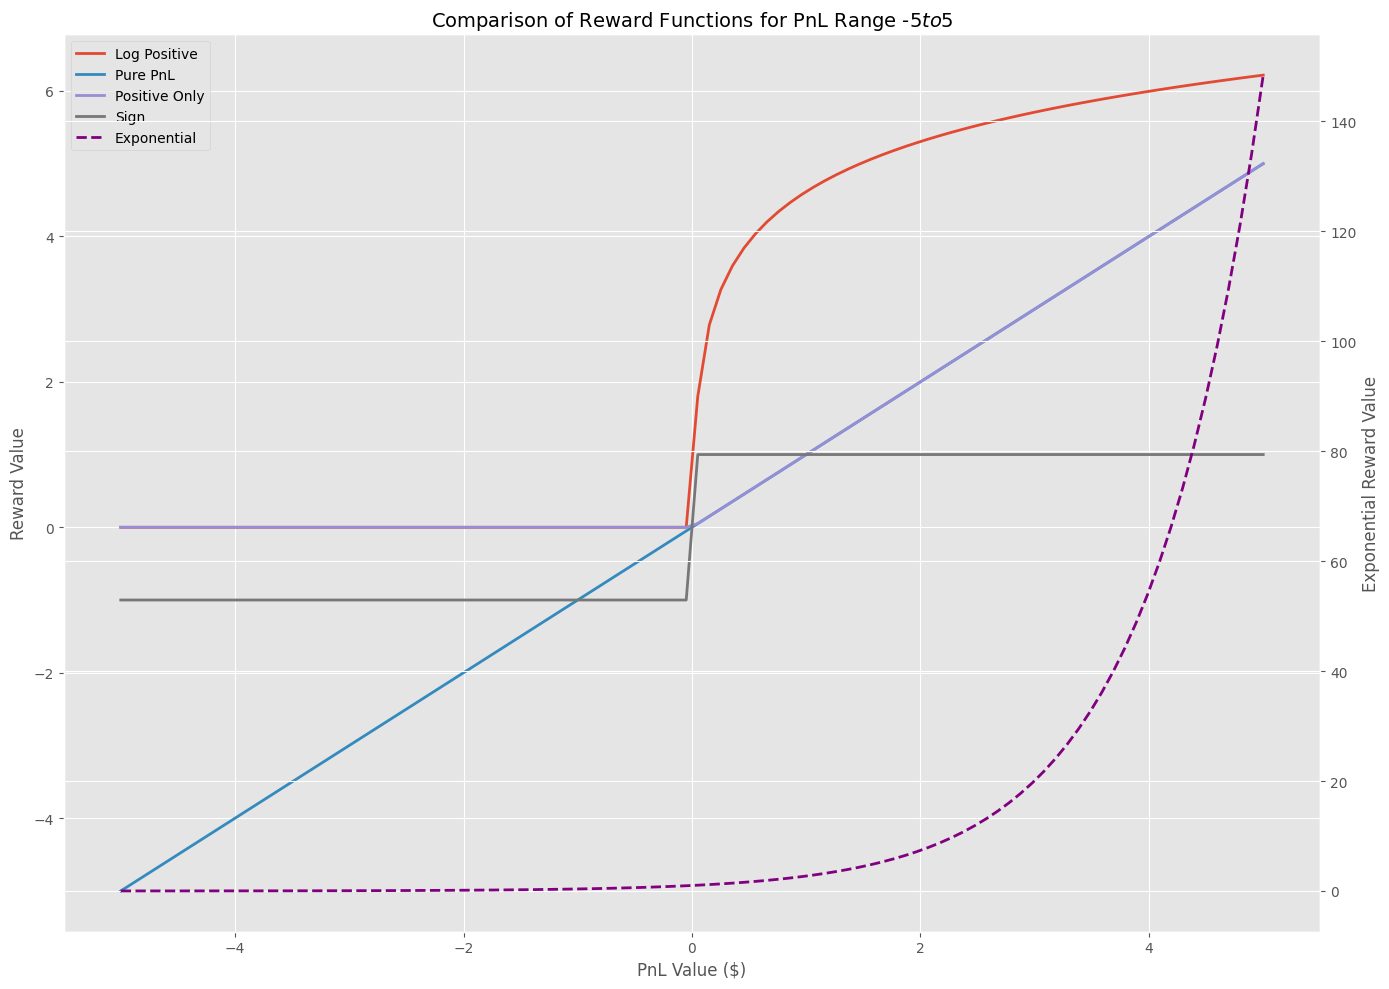

In [22]:
import numpy as np
import matplotlib.pyplot as plt

# Wrapper for all reward functions
def test_reward_functions(pnl_value, pos=1):
    entry = 1000
    curr = entry - (pnl_value * entry / pos)
    
    reward1 = reward_func_log_positive(entry, curr, pos)
    reward2 = reward_func_pure_pnl(entry, curr, pos)
    reward3 = reward_func_positive_only(entry, curr, pos)
    reward4 = reward_func_sign(entry, curr, pos)
    reward5 = reward_func_exponential(entry, curr, pos)
    
    return reward1, reward2, reward3, reward4, reward5

# PnL range -100 to 100
pnl_values = np.linspace(-5, 5, 100)
results = [test_reward_functions(pnl) for pnl in pnl_values]
rewards = np.array(results)

# Create figure and axis explicitly
fig, ax1 = plt.subplots(figsize=(14, 10))

# Plot rewards 1 to 4 on primary y-axis
ax1.plot(pnl_values, rewards[:, 0], label='Log Positive', linewidth=2)
ax1.plot(pnl_values, rewards[:, 1], label='Pure PnL', linewidth=2)
ax1.plot(pnl_values, rewards[:, 2], label='Positive Only', linewidth=2)
ax1.plot(pnl_values, rewards[:, 3], label='Sign', linewidth=2)

# Create secondary y-axis and plot exponential reward
ax2 = ax1.twinx()
ax2.plot(pnl_values, rewards[:, 4], label='Exponential', color='purple', linestyle='--', linewidth=2)

# Labels and title
ax1.set_xlabel('PnL Value ($)', fontsize=12)
ax1.set_ylabel('Reward Value', fontsize=12)
ax2.set_ylabel('Exponential Reward Value', fontsize=12)

ax1.set_title('Comparison of Reward Functions for PnL Range -$5 to $5', fontsize=14)

# Legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=10)

# Grid and layout
plt.grid(True)
plt.tight_layout()
plt.show()

Let's also print some example values to see the numerical differences at key PnL points:

In [23]:
print("Example reward values at different PnL points:")
print("PnL     | Log+  | Pure  | Pos   | Sign  | Exp   ")
print("--------|-------|-------|-------|-------|--------")
for pnl in [-10, -5, -1, 0, 1, 5, 10]:
    r1, r2, r3, r4, r5 = test_reward_functions(pnl)
    print(f"${pnl:6} | {r1:5.2f} | {r2:6.2f} | {r3:5.2f} | {r4:5.2f} | {r5:6.2f}")

Example reward values at different PnL points:
PnL     | Log+  | Pure  | Pos   | Sign  | Exp   
--------|-------|-------|-------|-------|--------
$   -10 |  0.00 | -10.00 |  0.00 | -1.00 |   0.00
$    -5 |  0.00 |  -5.00 |  0.00 | -1.00 |   0.01
$    -1 |  0.00 |  -1.00 |  0.00 | -1.00 |   0.37
$     0 |  0.00 |   0.00 |  0.00 |  0.00 |   1.00
$     1 |  4.62 |   1.00 |  1.00 |  1.00 |   2.72
$     5 |  6.22 |   5.00 |  5.00 |  1.00 | 148.41
$    10 |  6.91 |  10.00 | 10.00 |  1.00 | 22026.47


## Conclusion

Choosing the right reward function depends on your specific trading strategy objectives:

- For balancing win rate and magnitude: use **Pure PnL**
- For focusing only on profitable trades: use **Positive Only** reward
- For compressed positive rewards: use **Log Positive**
- For simple directional feedback: use **Sign** reward
- For heavily emphasizing large wins/losses: use **Exponential** reward

The ideal approach may involve testing multiple reward functions or even combining them to create a balanced learning signal for your trading algorithm.

Some considerations when selecting a reward function:

1. **Risk tolerance**: Functions that zero out losses might lead to riskier strategies
2. **Learning stability**: Binary or Sign functions provide more stable learning signals
3. **Reward magnitude**: Exponential function can create very large rewards that might destabilize learning
4. **Trading frequency**: Sign rewards might favor high-frequency, low-profit trades